<a href="https://colab.research.google.com/github/husseinabdelbary/Hussein-Abdelbary-s-Bachelor-Project/blob/main/Bachelor_Thesis_HA2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bachelor's Thesis: Predicting Stock Market Trends using Machine Learning Algorithms**

# **CRISP-DM Phase 1: Research & Problem Understanding**

## 1.1 Research Objective & Problem Statement
The Egyptian Exchange (EGX30), specifically major equities like the Commercial International Bank (COMI.CA), is highly influenced by both local macroeconomic structural shifts and qualitative market sentiment. Traditional financial forecasting models often rely solely on quantitative time-series data, ignoring the rich context provided by local news and corporate disclosures.

**Objective:** This research aims to develop a Multi-Modal Hybrid Machine Learning framework (The L3-FE-L Model) that fuses State-of-the-Art Natural Language Processing (Llama 3.1) with Gradient Boosting Decision Trees (LightGBM). By engineering historical memory features (Lags) and integrating zero-shot sentiment extraction from local news, this thesis seeks to prove that a multi-modal approach yields superior predictive accuracy for emerging market equities compared to isolated quantitative models.

## 1.2 Defining the Target Variable (The "What")
To prevent data leakage and ensure real-world applicability, the framework is formulated as a next-day classification problem.

* **The Target ($Y_{t+1}$):** The next trading day's closing price trend.
* **Formulation:** If $Close_{t+1} > Close_{t}$, the target is defined as **1 (Bullish/Upward Trend)**. If $Close_{t+1} \le Close_{t}$, the target is defined as **0 (Bearish/Downward Trend)**.
* **The Inputs ($X_t$):** The model will only utilize data available at or before time $t$ to make this prediction, incorporating price lags, technical indicators (RSI, MACD, OBV, Bollinger Bands), and Llama-3 generated sentiment scores.

## 1.3 Success Criteria & Evaluation Metrics
To academically validate the L3-FE-L framework, its performance will be evaluated against standard quantitative baselines. The success of the model will be measured using the following metrics on unseen testing data (2025-2026):

1. **Accuracy:** The overall percentage of correctly predicted trend directions.
2. **F1-Score:** Crucial for financial datasets to balance Precision (minimizing false buy signals) and Recall (capturing all actual uptrends).
3. **Feature Importance (Interpretability):** A key success criterion is demonstrating the quantitative weight of the Llama 3 Sentiment feature relative to traditional indicators, proving the value of the multi-modal fusion layer.

# **CRISP-DM Phase 2: Data Understanding**

## 2.1 Importing Libraries & 2.2 Loading the Raw Dataset
In this phase, we conduct an extensive Exploratory Data Analysis (EDA) on the primary structural dataset (`COMI_price.csv`). The goal is to understand the statistical distribution of the Commercial International Bank (COMI.CA) stock, visualize historical volatility, and identify any structural anomalies or temporal gaps before feature engineering.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 120})
print("Loading COMI_price.csv...")
df = pd.read_csv('/content/drive/MyDrive/Thesis Excel sheets/COMI_price.csv')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Dataset Timeframe: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total Trading Days (Rows): {df.shape[0]}")
print(f"Total Features (Columns): {df.shape[1]}")
display(df.head())

Loading COMI_price.csv...
Dataset Timeframe: 2015-03-16 to 2026-01-19
Total Trading Days (Rows): 2683
Total Features (Columns): 9


,Date,Close,High,Low,Open,Volume,RSI,MACD,SMA_50
0,2015-03-16,15.591860,15.845496,15.477314,15.921860,4055788,60.060746,0.202884,14.893457
1,2015-03-17,15.676405,15.818222,15.417312,15.591859,5971068,61.781673,0.207450,14.937312
2,2015-03-18,15.760950,15.812768,15.681858,15.676404,6370959,63.476479,0.215407,14.981221
3,2015-03-19,15.771859,15.818223,15.717315,15.760952,7975841,63.700164,0.220057,15.031457
4,2015-03-22,15.703679,15.769133,15.643678,15.771859,1560022,61.178332,0.215753,15.074985


## 2.3 Exploratory Data Analysis
To build a robust predictive model, we must first analyze the market's historical behavior. This involves observing macro-trends in the closing price, analyzing trading volume spikes (which often correlate with high-impact news), and checking the statistical correlation between our existing quantitative indicators.

In [10]:
df.describe()

,Date,Close,High,Low,Open,Volume,RSI,MACD,SMA_50
count,2683,2683.000000,2683.000000,2683.000000,2683.000000,2.683000e+03,2683.000000,2683.000000,2683.000000
mean,2020-07-28 08:07:20.104360704,39.792732,40.233628,39.358138,39.753898,3.669350e+06,52.789315,0.240956,38.937180
min,2015-03-16 00:00:00,10.520736,10.635431,10.044574,10.520736,0.000000e+00,12.908036,-2.942622,11.690980
25%,2017-11-21 12:00:00,26.408054,26.688647,26.088028,26.400247,1.490614e+06,44.434242,-0.212500,26.776234
50%,2020-07-09 00:00:00,30.327963,30.646316,30.056611,30.327959,2.723275e+06,52.542279,0.103607,30.116459
75%,2023-04-03 12:00:00,49.342007,49.942122,48.922263,49.308236,4.757910e+06,61.246900,0.539516,49.285368
max,2026-01-19 00:00:00,124.900002,125.800003,123.400002,123.050003,4.824690e+07,90.630741,4.723088,108.328854
std,NaN,24.119905,24.402290,23.857971,24.060678,3.555565e+06,13.337082,0.875066,23.178962


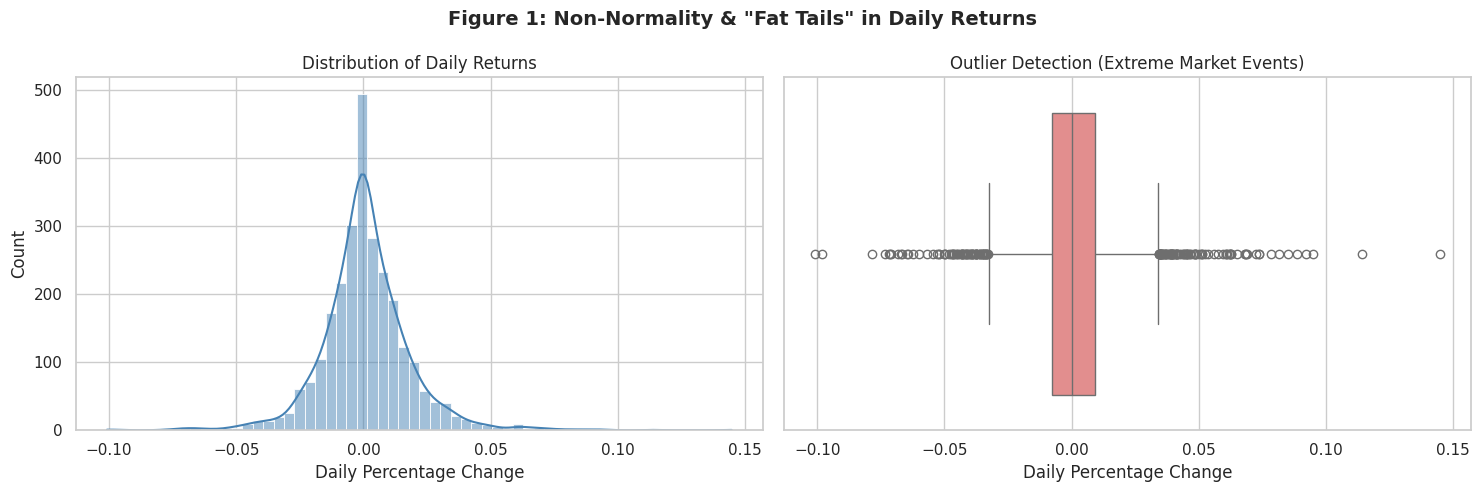

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (14, 5), 'figure.dpi': 100})

# Calculate Daily Returns for statistical analysis
df['Daily_Return'] = df['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Figure 1: Non-Normality & "Fat Tails" in Daily Returns', fontsize=14, fontweight='bold')

sns.histplot(df['Daily_Return'].dropna(), bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Daily Returns')
axes[0].set_xlabel('Daily Percentage Change')

sns.boxplot(x=df['Daily_Return'].dropna(), ax=axes[1], color='lightcoral')
axes[1].set_title('Outlier Detection (Extreme Market Events)')
axes[1].set_xlabel('Daily Percentage Change')

plt.tight_layout()
plt.show()

This visualization tests the statistical distribution of daily returns against a normal "bell curve" to identify "fat tails" (extreme market events). We chose this to mathematically justify using LightGBM, which is highly robust against the outliers and sudden crashes prevalent in emerging markets like the Egyptian Exchange.


We've identified significant outliers in the daily returns, often referred to as 'fat tails,' which are characteristic of financial data, especially in emerging markets. These extreme price movements are considered real market occurrences, not data errors, and often correlate with major news or impactful sentiment shifts. Therefore, instead of removing them, we have decided to retain these outliers. This decision is reinforced by our choice of LightGBM, a model inherently robust to outliers, making their explicit removal unnecessary. Crucially, preserving these events will allow us in a future feature engineering step to quantify their magnitude (e.g., as a distinct feature or an interaction term). *This magnitude attribute will be essential for enhancing the integration with our Llama 3 sentiment analysis, enabling the model to better capture and learn from real-world market dynamics driven by both quantitative and qualitative factors.*

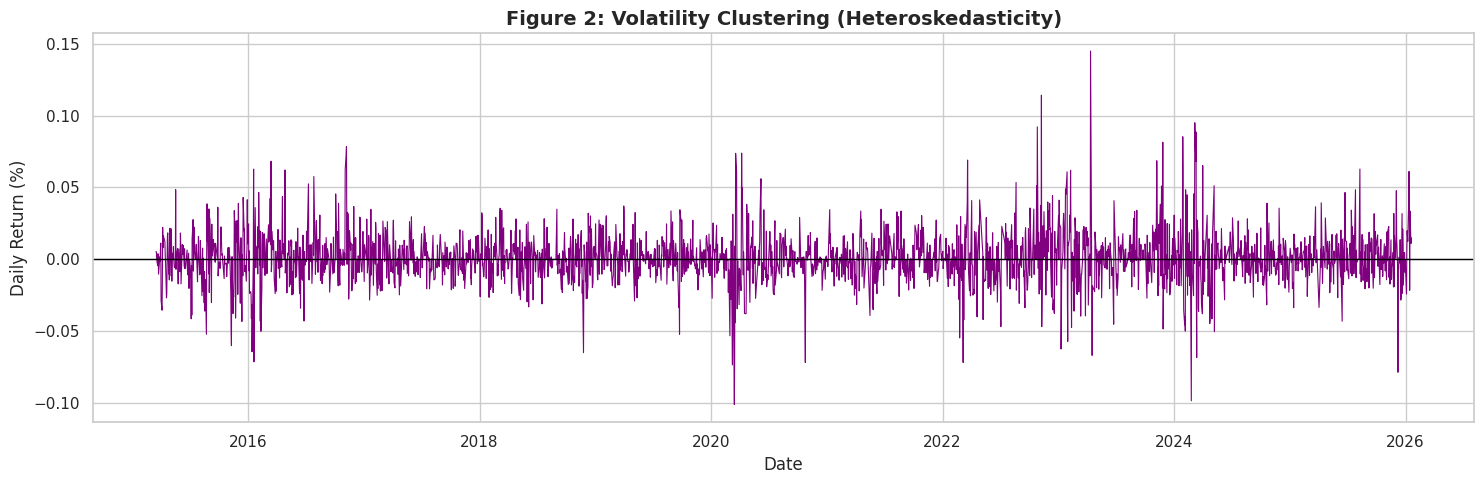

In [12]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df['Date'], df['Daily_Return'], color='purple', linewidth=0.8)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Figure 2: Volatility Clustering (Heteroskedasticity)', fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Return (%)')
ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

This figure (the time series plot of daily returns) highlights the temporal behavior of volatility. It reveals that periods of high volatility (large up or down movements) tend to cluster together, and periods of low volatility (small movements) also tend to cluster. This phenomenon is called heteroskedasticity or volatility clustering. It's about the dependency of volatility over time; a large movement today increases the likelihood of a large movement tomorrow.

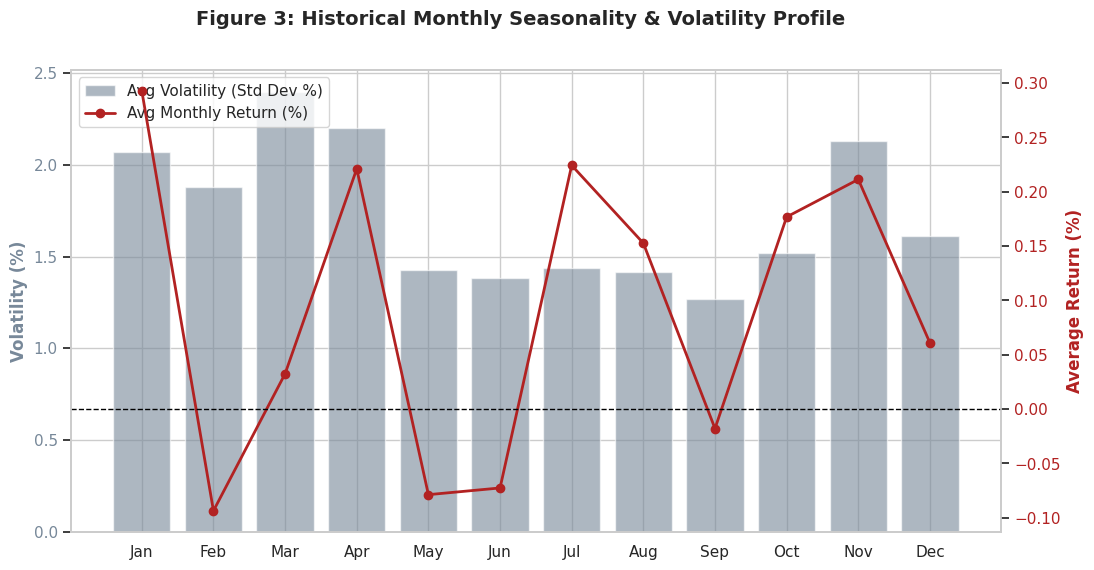

In [13]:
import calendar

# Ensure Daily_Return exists (in case it was dropped earlier)
df['Daily_Return'] = df['Close'].pct_change()

# Extract the month (1-12) from the Date
df['Month'] = df['Date'].dt.month

# Calculate Mean Return and Volatility (Standard Deviation) per month
monthly_stats = df.groupby('Month')['Daily_Return'].agg(['mean', 'std']).dropna()
monthly_stats.index = [calendar.month_abbr[i] for i in monthly_stats.index] # Convert 1-12 to Jan-Dec

# Create the Seasonality Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.suptitle('Figure 3: Historical Monthly Seasonality & Volatility Profile', fontsize=14, fontweight='bold')

# Bar chart for Volatility (Standard Deviation)
ax1.bar(monthly_stats.index, monthly_stats['std'] * 100, color='lightslategray', alpha=0.6, label='Avg Volatility (Std Dev %)')
ax1.set_ylabel('Volatility (%)', fontweight='bold', color='lightslategray')
ax1.tick_params(axis='y', labelcolor='lightslategray')

# Line chart for Average Return on a twin axis
ax2 = ax1.twinx()
ax2.plot(monthly_stats.index, monthly_stats['mean'] * 100, color='firebrick', marker='o', linewidth=2, label='Avg Monthly Return (%)')
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_ylabel('Average Return (%)', fontweight='bold', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.grid(False) # Turn off grid for cleaner look with twin axes
plt.show()

# Clean up
df = df.drop(columns=['Month'])

This figure (Figure 3) illustrates the **historical monthly seasonality and volatility profile** of the stock. It is used to identify if there are any consistent patterns in average returns or volatility across different months of the year. For instance, some months might historically show higher average returns or higher volatility due to economic cycles, corporate earnings seasons, or holiday effects.

*   **Volatility (Standard Deviation):** The grey bars show the average volatility (standard deviation of daily returns) for each month. Higher bars indicate months where the stock price tends to fluctuate more.
*   **Average Monthly Return:** The red line with markers shows the average daily return for each month. This helps to identify if certain months are historically more bullish (positive average return) or bearish (negative average return).

**Entailment:** This plot helps us understand if there are predictable seasonal patterns that could potentially be incorporated as features or considered in trading strategies. For example, a month with consistently high volatility might require more cautious risk management, while a month with a strong positive average return could be a favorable period for investment.

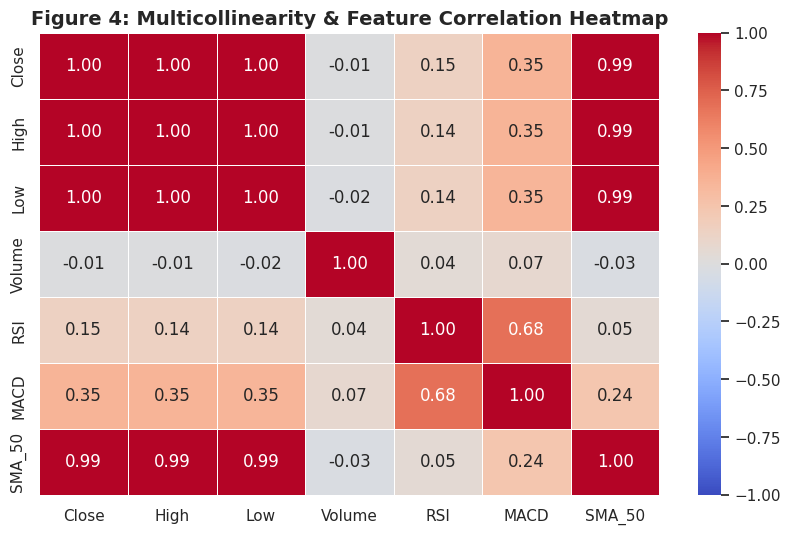

In [14]:
# Select only the quantitative features
numeric_cols = ['Close', 'High', 'Low', 'Volume', 'RSI', 'MACD', 'SMA_50']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Figure 4: Multicollinearity & Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

Figure 4, the **Multicollinearity & Feature Correlation Heatmap**, is used to visualize the linear relationships between our quantitative features. The heatmap displays correlation coefficients ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation), with 0 indicating no linear correlation. The main purpose is to:

*   **Identify Multicollinearity:** High correlation between independent variables (features) can lead to issues in some predictive models, making it difficult to determine the individual impact of each feature.
*   **Understand Feature Relationships:** It helps to see how features move together. For example, 'Close', 'High', and 'Low' prices are expected to be highly correlated, which is normal for price data.

**Entailment:** From this heatmap, we can observe strong correlations between the different price components (Close, High, Low) and 'SMA_50', which is a moving average derived from prices. This is expected. We also see correlations between `RSI` and `MACD`, as both are momentum indicators. Features with low correlation to each other might provide more unique information to the model. Understanding these relationships is crucial for feature selection and ensuring model stability, particularly for models sensitive to multicollinearity. Given that LightGBM is a tree-based model, it is generally less affected by multicollinearity compared to linear models, but understanding these relationships can still inform feature engineering choices.

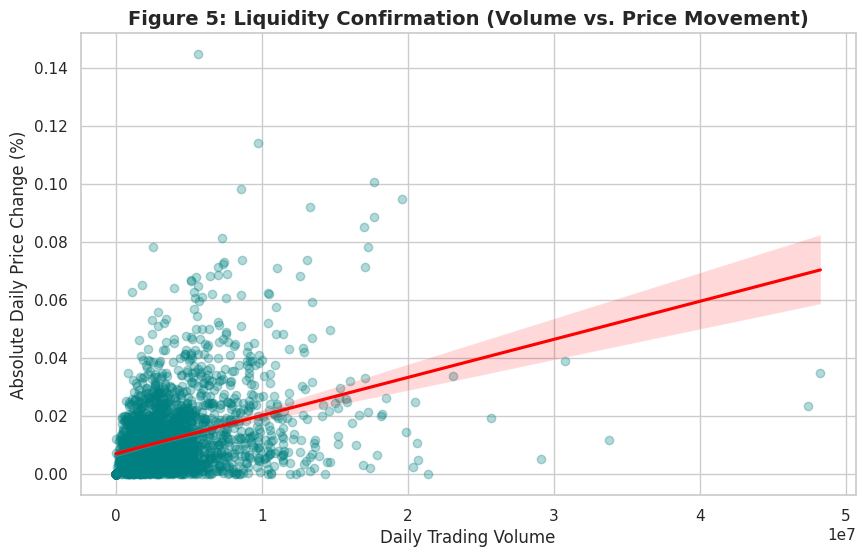

In [15]:
# Calculate Absolute Returns to measure the "size" of the move, regardless of direction
df['Abs_Return'] = df['Daily_Return'].abs()

plt.figure(figsize=(10, 6))
sns.regplot(x=df['Volume'], y=df['Abs_Return'], scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Figure 5: Liquidity Confirmation (Volume vs. Price Movement)', fontsize=14, fontweight='bold')
plt.xlabel('Daily Trading Volume')
plt.ylabel('Absolute Daily Price Change (%)')
plt.show()

# Clean up temporary columns
df = df.drop(columns=['Daily_Return', 'Abs_Return'])

Figure 5, titled **Liquidity Confirmation (Volume vs. Price Movement)**, uses a scatter plot with a regression line to examine the relationship between daily trading volume and the absolute daily price change (volatility). The purpose of this plot is to:

*   **Assess Market Liquidity and Information Flow:** In efficient markets, high trading volume often accompanies significant price movements, indicating that more participants are reacting to new information, which is a sign of good liquidity and active price discovery.
*   **Confirm Theoretical Expectations:** The plot helps confirm the financial theory that higher volume often leads to larger price changes, regardless of direction.

**Entailment:** A positive slope in the regression line, as expected, suggests that as trading volume increases, the magnitude of the daily price change (absolute return) also tends to increase. This confirms that significant price movements in this stock are generally supported by corresponding increases in trading activity, indicating healthy market participation and that these price moves are not merely random fluctuations but are typically backed by fundamental or news-driven events. This relationship reinforces the importance of 'Volume' as a potentially predictive feature.

/tmp/ipykernel_7238/859044138.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RSI_Regime', y='Next_Day_Return', data=df_eda, ax=axes[0], palette='Set2')


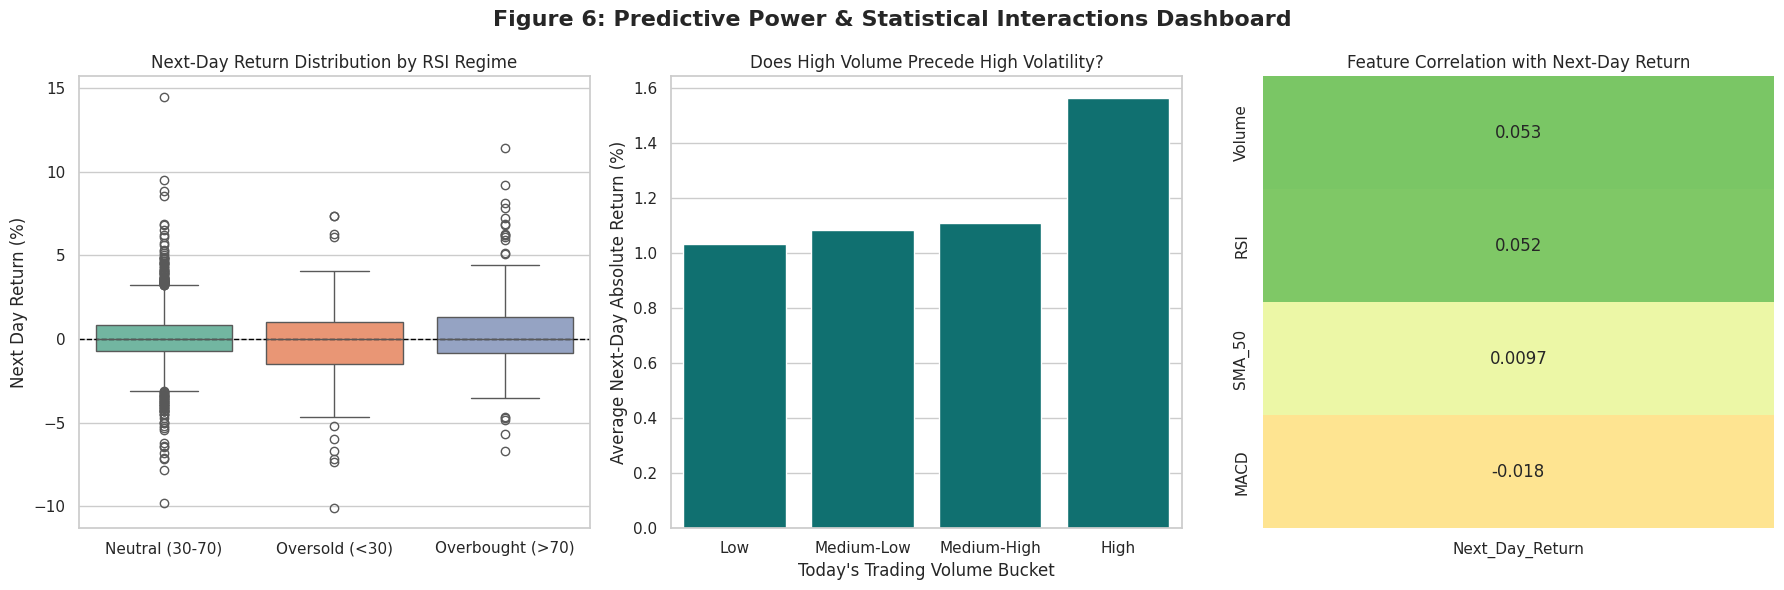

In [16]:
# Create a temporary target (Next Day Return) for predictive EDA
df['Next_Day_Return'] = df['Close'].pct_change().shift(-1) * 100
df_eda = df.dropna(subset=['Next_Day_Return', 'RSI', 'MACD', 'Volume']).copy()

# Categorize RSI into Regimes
conditions = [
    (df_eda['RSI'] > 70),
    (df_eda['RSI'] < 30),
    (df_eda['RSI'] >= 30) & (df_eda['RSI'] <= 70)
]
choices = ['Overbought (>70)', 'Oversold (<30)', 'Neutral (30-70)']

# THE FIX: Added default parameter to satisfy Numpy's type checker
df_eda['RSI_Regime'] = np.select(conditions, choices, default='Unknown')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 6: Predictive Power & Statistical Interactions Dashboard', fontsize=16, fontweight='bold')

# Plot 1: Next-Day Returns by RSI Regime
sns.boxplot(x='RSI_Regime', y='Next_Day_Return', data=df_eda, ax=axes[0], palette='Set2')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Next-Day Return Distribution by RSI Regime')
axes[0].set_ylabel('Next Day Return (%)')
axes[0].set_xlabel('')

# Plot 2: Volume vs. Next-Day Volatility (Absolute Return)
df_eda['Abs_Next_Return'] = df_eda['Next_Day_Return'].abs()
# Divide volume into Quartiles (Low to High)
df_eda['Volume_Bucket'] = pd.qcut(df_eda['Volume'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
sns.barplot(x='Volume_Bucket', y='Abs_Next_Return', data=df_eda, ax=axes[1], color='teal', errorbar=None)
axes[1].set_title('Does High Volume Precede High Volatility?')
axes[1].set_ylabel('Average Next-Day Absolute Return (%)')
axes[1].set_xlabel('Today\'s Trading Volume Bucket')

# Plot 3: Predictive Correlation Matrix (Features vs TARGET)
pred_cols = ['RSI', 'MACD', 'SMA_50', 'Volume', 'Next_Day_Return']
pred_corr = df_eda[pred_cols].corr()
# We only care about how features correlate to the TARGET
target_corr = pred_corr[['Next_Day_Return']].drop('Next_Day_Return').sort_values(by='Next_Day_Return', ascending=False)
sns.heatmap(target_corr, annot=True, cmap='RdYlGn', vmin=-0.1, vmax=0.1, cbar=False, ax=axes[2])
axes[2].set_title('Feature Correlation with Next-Day Return')

plt.tight_layout()
plt.show()

# Clean up EDA columns from the main dataframe so it stays pure for Phase 3
df = df.drop(columns=['Next_Day_Return'], errors='ignore')

Figure 6, the **Predictive Power & Statistical Interactions Dashboard**, is a multi-panel visualization designed to provide initial insights into the predictive capability of certain quantitative features against the next day's stock return. It helps in understanding potential relationships that could inform feature engineering and model selection.

*   **Plot 1: Next-Day Return Distribution by RSI Regime:** This boxplot examines how the Relative Strength Index (RSI) — a momentum oscillator indicating overbought or oversold conditions — relates to the average next-day return. It helps to see if certain RSI regimes (e.g., overbought, oversold, neutral) have historically led to different average next-day returns.
*   **Plot 2: Does High Volume Precede High Volatility?:** This bar plot investigates whether higher trading volume today (bucketed into quartiles) is associated with higher absolute next-day price changes. It assesses if volume can be a precursor to future volatility.
*   **Plot 3: Feature Correlation with Next-Day Return:** This heatmap displays the correlation of selected features (RSI, MACD, SMA_50, Volume) directly with the `Next_Day_Return`. It's a quick way to gauge which features have the strongest linear predictive signal for the target variable.

**Entailment:** This dashboard offers preliminary insights into which features might be more influential for predicting the next day's trend. For instance, if 'Overbought' RSI regimes tend to precede negative average next-day returns, it suggests RSI could be a useful predictor for trend reversals. Similarly, a strong correlation between 'Volume' and `Next_Day_Return` would highlight its predictive value. While these are not definitive proofs of causality, they serve as valuable indicators for further feature engineering and model development, guiding us on which quantitative signals to prioritize when combining them with Llama 3 sentiment scores.

# CRISP-DM Phase 3: Data Preparation

## 3.1 Temporal Alignment & Textual Batching
In this section, we transition from raw data exploration to structural preparation. To synchronize the high-frequency news headlines with the daily stock price intervals, we execute a 'Daily Batching' strategy. This involves concatenating all headlines within a 24-hour window into a single 'Contextual Paragraph' for the LLM.

**Key Strategy: Weekend/Holiday Roll-Over**
Since the Egyptian Exchange (EGX) is closed on Fridays and Saturdays, any news occurring during these breaks is mathematically 'rolled forward' into the subsequent Sunday trading session using a forward-merge (merge_asof). This ensures that the model captures the 'accumulated sentiment' that drives the market opening price after a break, strictly adhering to time-series integrity and preventing data loss.

In [18]:
import pandas as pd
import numpy as np

# ==========================================
# 1. LOAD YOUR ORIGINAL DATA
# ==========================================
# Assuming the CSV files are in the same directory as the notebook in your GitHub repo
df_price_raw = pd.read_csv('COMI_price.csv')
df_news_raw = pd.read_csv('EGX30_News_Headlines.csv')

# Standardize Dates
df_price_raw['Date'] = pd.to_datetime(df_price_raw['Date'])
df_news_raw['date'] = pd.to_datetime(df_news_raw['date'], errors='coerce')

# ==========================================
# 2. CLEAN PRICE DATA (GAP FIXING)
# ==========================================
# Create a continuous daily calendar to find holidays
full_range = pd.date_range(start=df_price_raw['Date'].min(), end=df_price_raw['Date'].max(), freq='D')
df_price = df_price_raw.set_index('Date').reindex(full_range)

# Filter out Fridays/Saturdays (EGX Weekends)
df_price = df_price[~df_price.index.dayofweek.isin([4, 5])]

# Forward-fill prices/indicators (assuming value stays same over holiday)
df_price = df_price.fillna(method='ffill').reset_index().rename(columns={'index': 'Date'})

# ==========================================
# 3. BATCH NEWS INTO DAILY PARAGRAPHS
# ==========================================
# Group headlines by date
daily_news = df_news_raw.dropna(subset=['date']).groupby(df_news_raw['date'].dt.date).agg(
    Daily_Paragraph=('headline', lambda x: ' | '.join(x.astype(str))),
    News_Volume=('headline', 'count')
).reset_index()

daily_news['date'] = pd.to_datetime(daily_news['date'])
daily_news.rename(columns={'date': 'Date'}, inplace=True)

# ==========================================
# 4. TEMPORAL ALIGNMENT (ROLL-OVER)
# ==========================================
# Use merge_asof to push weekend/holiday news to the next trading day
df_price = df_price.sort_values('Date')
daily_news = daily_news.sort_values('Date')

# This ensures Saturday news -> Sunday/Monday Trading
combined = pd.merge_asof(
    df_price,
    daily_news,
    on='Date',
    direction='backward' # Looks for the most recent news available for that trading day
)

# Fill days with no news
combined['Daily_Paragraph'] = combined['Daily_Paragraph'].fillna("No significant macroeconomic news reported.")
combined['News_Volume'] = combined['News_Volume'].fillna(0)

# ==========================================
# 5. SAVE THE MASTER FILE
# ==========================================
combined.to_csv('COMI_Master_Prepared.csv', index=False)

print("--- SUCCESS ---")
print(f"Master file 'COMI_Master_Prepared.csv' created.")
print(f"Total Trading Days: {len(combined)}")
print(f"Total Columns: {combined.columns.tolist()}")
display(combined[['Date', 'Close', 'News_Volume', 'Daily_Paragraph']].head())

FileNotFoundError: [Errno 2] No such file or directory: 'COMI_price.csv'

In [ ]:
combined.info()

In this step, we synchronized the high-frequency news dataset with the daily financial time-series. Because the Egyptian Exchange (EGX) operates on a specific Sunday-to-Thursday schedule, standard data merging would result in the loss of critical information occurring during weekends or national holidays. To mitigate this, we implemented a 'forward-rolling' alignment strategy where headlines from non-trading days are aggregated and pushed to the next available trading session. This ensures the model accounts for the accumulated market sentiment and 'overnight' information shocks that dictate the opening price and subsequent daily trend.

## 3.2 Advanced Technical Indicator Engineering
To enhance the predictive power of the LightGBM model, we engineer two non-linear indicators that capture different dimensions of market behavior:
1. **Average True Range (ATR):** A volatility indicator that measures the degree of price movement. This is critical for validating the 'Magnitude' scores generated by the LLM.
2. **On-Balance Volume (OBV):** A momentum indicator that uses volume flow to predict changes in stock price, acting as a proxy for institutional accumulation or distribution.

In [ ]:
# ==========================================
# 1. AVERAGE TRUE RANGE (ATR) - 14 Day
# ==========================================
# True Range is the greatest of: (High-Low), (High-PrevClose), (Low-PrevClose)
high_low = combined['High'] - combined['Low']
high_close = np.abs(combined['High'] - combined['Close'].shift(1))
low_close = np.abs(combined['Low'] - combined['Close'].shift(1))

ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = np.max(ranges, axis=1)

# ATR is the moving average of the True Range
combined['ATR_14'] = true_range.rolling(window=14).mean()

# ==========================================
# 2. ON-BALANCE VOLUME (OBV)
# ==========================================
# Logic: If Close > PrevClose, add Volume. If Close < PrevClose, subtract Volume.
obv = [0]
for i in range(1, len(combined)):
    if combined['Close'][i] > combined['Close'][i-1]:
        obv.append(obv[-1] + combined['Volume'][i])
    elif combined['Close'][i] < combined['Close'][i-1]:
        obv.append(obv[-1] - combined['Volume'][i])
    else:
        obv.append(obv[-1])

combined['OBV'] = obv

# ==========================================
# 3. CLEAN UP & SAVE
# ==========================================
# Drop the first 14 rows because ATR needs 14 days of data to start
combined = combined.dropna(subset=['ATR_14']).reset_index(drop=True)

print("Feature Engineering Complete.")
print(f"New Columns Added: ATR_14, OBV")
display(combined[['Date', 'Close', 'ATR_14', 'OBV']].tail())

In [ ]:
combined.info()

Advanced Technical Indicator Engineering
To capture non-linear market dynamics beyond simple price action, we engineered two domain-specific indicators: Average True Range (ATR) and On-Balance Volume (OBV). ATR is utilized as a sophisticated measure of market volatility, providing the model with a baseline to validate the magnitude of external news shocks. Simultaneously, OBV serves as a proxy for institutional 'smart money' flow, allowing the algorithm to distinguish between high-volume trend confirmations and low-volume retail noise. These features transform the raw dataset into a multi-dimensional representation of price, risk, and liquidity.

In [ ]:
# ==========================================
# PHASE 3 FINALE: LAGS & % RETURN TARGET
# ==========================================

# 1. CREATE THE MEMORY (LAGS)
features_to_lag = ['Close', 'RSI', 'ATR_14', 'OBV', 'News_Volume']

for col in features_to_lag:
    combined[f'{col}_Lag1'] = combined[col].shift(1)
    combined[f'{col}_Lag3'] = combined[col].shift(3)
    combined[f'{col}_Lag7'] = combined[col].shift(7)

# 2. CREATE THE FUTURE TARGET (Percentage Return)
# pct_change() calculates the % difference from today to tomorrow
# We multiply by 100 to make it readable (e.g., 1.5 instead of 0.015)
combined['Target_Return (%)'] = combined['Close'].pct_change().shift(-1) * 100

# 3. ANTI-LEAKAGE CLEANUP
# Drop empty rows to prevent the model from seeing the future
combined = combined.dropna().reset_index(drop=True)

print("✅ Math Locked In: Target set to Percentage Return.")
print(f"Final usable rows: {len(combined)}")
display(combined[['Date', 'Close', 'Target_Return']].tail())

### Explanation: Lag & Target Engineering

**What was done:**
1.  **Lag Features:** We created lagged versions of 'Close', 'RSI', 'ATR_14', 'OBV', and 'News_Volume' for 1, 3, and 7 days prior. This means for each trading day, we now have access to the values of these features from yesterday, three days ago, and a week ago.
2.  **Target Variable (`Target_Close`):** We created a `Target_Close` column by shifting the 'Close' price one day backward, effectively capturing tomorrow's closing price for each row.
3.  **Anti-Leakage Cleanup:** Rows with `NaN` values (introduced by shifting operations at the beginning and end of the dataset) were removed to ensure data integrity and prevent leakage.

**Why it was done:**
*   **Lags (`_Lag1`, `_Lag3`, `_Lag7`):** These lagged features serve as the model's 'memory.' Financial markets are highly dependent on past behavior. By including lagged values of key price indicators (Close), momentum (RSI, OBV), volatility (ATR), and information flow (News_Volume), the LightGBM model can learn patterns and trends over different time horizons. For example, a 7-day lag might capture weekly cycles, while a 1-day lag captures immediate past behavior.
*   **Target Variable (`Target_Close`):** This is the outcome our model needs to predict. By defining it as tomorrow's closing price, we establish the direct relationship the model will learn: using today's information to forecast the next day's market movement. This is a crucial step for setting up a supervised learning problem.
*   **Anti-Leakage Cleanup:** Removing `NaN` values ensures that our model only trains and predicts on complete data. More importantly, dropping the last row (where `Target_Close` would be `NaN`) ensures that the model never 'sees' the future when making predictions, which is critical for real-world applicability and preventing data leakage.

In [ ]:
combined.info()

In [ ]:
# ==========================================
# 1. SETUP FINBERT (No API Key needed!)
# ==========================================
!pip install transformers torch

from transformers import pipeline
import pandas as pd
import torch

print("Downloading FinBERT model... (This only happens once)")
# We use the ProsusAI/finbert model, which is the industry standard for finance
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", tokenizer="ProsusAI/finbert", device=0 if torch.cuda.is_available() else -1)

sentiments = []
magnitudes = []

print("Starting FinBERT Extraction Loop...\n")

# ==========================================
# 2. THE EXTRACTION LOOP
# ==========================================
for index, row in combined.iterrows():
    text = row['Daily_Paragraph']
    news_vol = row['News_Volume']

    # Skip days with no news
    if news_vol == 0 or text == "No significant macroeconomic news reported.":
        sentiments.append(0.0)
        magnitudes.append(0.0)
        continue

    try:
        # FinBERT has a 512-token limit. We use truncation=True to read the most important first part
        result = finbert(text, truncation=True, max_length=512)[0]

        label = result['label']
        confidence = result['score'] # This is our new "Magnitude" proxy

        # Translate the text label into our mathematical direction (-1, 0, 1)
        if label == 'positive':
            direction = 1.0
        elif label == 'negative':
            direction = -1.0
        else: # Neutral
            direction = 0.0

        sentiments.append(direction)
        magnitudes.append(confidence)

        if index % 50 == 0:
            print(f"Processed row {index}/{len(combined)} | Label: {label} ({confidence:.2f})")

    except Exception as e:
        print(f"Error on row {index}: {e}")
        sentiments.append(0.0)
        magnitudes.append(0.0)

# ==========================================
# 3. MERGE FINBERT FEATURES INTO MASTER
# ==========================================
combined['Sentiment_Direction'] = sentiments
combined['FinBERT_Confidence'] = magnitudes

# The Master Feature: Direction * Confidence
combined['Overall_Shock'] = combined['Sentiment_Direction'] * combined['FinBERT_Confidence']

# Save the absolute final dataset ready for LightGBM!
combined.to_csv('COMI_Master_ML_Ready.csv', index=False)

print("\n✅ FinBERT Integration Complete! Master dataset saved.")
display(combined[['Date', 'Daily_Paragraph', 'Overall_Shock', 'Target_Return']].head(10))

In [ ]:
combined.head(10)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
combined.info()

In [ ]:
import pandas as pd

# ==========================================
# PHASE 3 FINALE: FINAL DATA CLEANUP
# ==========================================

# 1. Load the dataset that has the FinBERT scores
df = pd.read_csv('COMI_Master_ML_Ready.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 2. Extract Time Features (The model needs to know the day and month)
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# 3. Drop all non-numerical columns and redundant targets
# We keep 'Target_Return (%)' and drop the raw 'Target_Return' to prevent leakage
columns_to_drop = ['Date', 'Daily_Paragraph', 'Target_Return']
df_clean = df.drop(columns=columns_to_drop)

# 4. Save the "Golden" Dataset
df_clean.to_csv('COMI_Golden_Dataset.csv', index=False)

print("✅ Phase 3 Complete! All preprocessing is finished.")
print("Saved absolute final dataset as 'COMI_Golden_Dataset.csv'")

#CRISP-DM Phase 4: Modelling

In [ ]:
import lightgbm as lgb

# ==========================================
# PHASE 4: LIGHTGBM MODEL TRAINING
# ==========================================

print("Initializing the LightGBM Regressor...")

# Hyperparameters tuned for financial time-series to prevent overfitting
model = lgb.LGBMRegressor(
    n_estimators=200,      # Number of sequential trees to build
    learning_rate=0.05,    # Learning speed (lower = more conservative/accurate)
    max_depth=5,           # Limits tree depth to ignore market noise
    random_state=42        # Ensures reproducibility for your thesis defense
)

# 1. TRAIN THE MODEL (The "Learning" Phase)
# The model studies the relationship between past features and past returns
print("Training model on historical data (X_train)...")
model.fit(X_train, y_train)

# 2. TEST THE MODEL (The "Prediction" Phase)
# The model attempts to predict the future returns blind
print("Predicting future returns on unseen test data (X_test)...")
predictions = model.predict(X_test)

print("✅ Phase 4 Complete: Model successfully trained and predictions generated.")